# Предсказание стоимости автомобилей BMW

## Введение

В данной работе рассматривается задача регрессии на основе реальных данных аукциона B2B за 2018 год. Датасет содержит информацию о ~4800 подержанных автомобилях марки BMW, включая технические характеристики, дату регистрации, тип топлива, цвет, класс кузова, а также 8 бинарных признаков комплектации (`feature_1`–`feature_8`). Целевой переменной является `price` — итоговая цена продажи (максимальная ставка на аукционе).

Данные предварительно очищены от автомобилей с критическими повреждениями двигателя, однако могут присутствовать незначительные дефекты, информация о которых отсутствует.

## Задача

1. Обработайте набор данных, подготовив его к решению задачи регрессии/классификации. Целевой признак указан в последнем столбце таблицы.

2. Разделите набор данных на обучающую и тестовую выборку (80/20).

3. Примените модель линейной/логистической регрессии. Оцените точность построенной модели.

4. Постарайтесь улучшить результат. Модель настраивать можно (в т.ч. регуляризация), менять нельзя.

Загружаем основные инструменты для работы с данными:
- `pandas` и `numpy` для обработки таблиц и вычислений.
- `matplotlib` и `seaborn` для визуализации распределений и корреляций.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Загружаем датасет с аукциона B2B.

In [4]:
df = pd.read_csv('data.csv')
df

,maker_key,model_key,mileage,engine_power,registration_date,fuel,paint_color,car_type,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,price
0,BMW,118,140411,100.0,2012-02-01,diesel,black,convertible,True,True,False,False,True,True,True,False,11300
1,BMW,M4,13929,317.0,2016-04-01,petrol,grey,convertible,True,True,False,False,False,True,True,True,69700
2,BMW,320,183297,120.0,2012-04-01,diesel,white,convertible,False,False,False,False,True,False,True,False,10200
3,BMW,420,128035,135.0,2014-07-01,diesel,red,convertible,True,True,False,False,True,True,True,True,25100
4,BMW,425,97097,160.0,2014-12-01,diesel,silver,convertible,True,True,False,False,False,True,True,True,33400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4838,BMW,218 Gran Tourer,39743,NaN,2015-10-01,diesel,black,van,False,True,False,False,False,False,True,False,14600
4839,BMW,218 Active Tourer,49832,100.0,2015-06-01,diesel,grey,van,False,True,False,False,False,False,True,True,17500
4840,BMW,218 Gran Tourer,19633,110.0,2015-10-01,diesel,grey,van,False,True,False,False,False,False,True,True,17000
4841,BMW,218 Active Tourer,27920,110.0,2016-04-01,diesel,brown,NaN,True,True,False,False,False,False,True,True,22700


В таблице представлены характеристики автомобилей BMW: модель, пробег, мощность, дата регистрации, тип топлива, цвет, кузов и наличие дополнительных опций (`feature_1`–`feature_8`).
Целевая переменная — `price` (цена продажи).

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   maker_key          4843 non-null   object 
 1   model_key          4843 non-null   object 
 2   mileage            4843 non-null   int64  
 3   engine_power       4591 non-null   float64
 4   registration_date  4843 non-null   object 
 5   fuel               4843 non-null   object 
 6   paint_color        4819 non-null   object 
 7   car_type           4530 non-null   object 
 8   feature_1          4843 non-null   bool   
 9   feature_2          4843 non-null   bool   
 10  feature_3          4843 non-null   bool   
 11  feature_4          4843 non-null   bool   
 12  feature_5          4843 non-null   bool   
 13  feature_6          4843 non-null   bool   
 14  feature_7          4843 non-null   bool   
 15  feature_8          4843 non-null   bool   
 16  price              4843 

Проверяем типы данных и наличие пропусков.
Видим, что в столбцах `engine_power`, `paint_color` и `car_type` есть значения (NaN), которые потребуют обработки. Столбец `maker_key` содержит только одно значение ('BMW') и не несет информационной нагрузки.

In [8]:
df = df.drop('maker_key', axis=1)

Построим boxplot для мощности двигателя (`engine_power`), чтобы оценить разброс значений и наличие аномалий перед заполнением пропусков.

<Axes: ylabel='engine_power'>

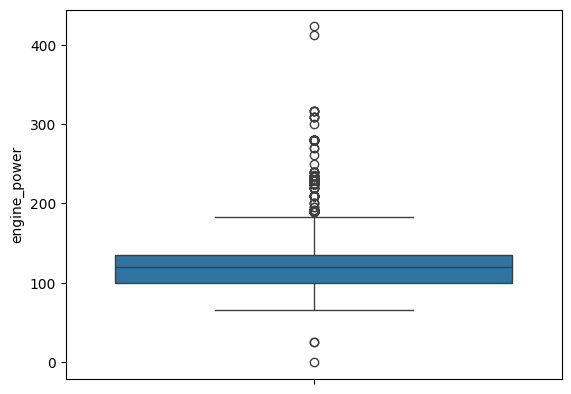

In [9]:
sns.boxplot(df['engine_power'])

Заполняем пропущенные значения модой (наиболее часто встречающимся значением) для следующих признаков:
- `engine_power`
- `paint_color`
- `car_type`

Использование моды позволяет сохранить общую структуру распределения категориальных и числовых признаков, не внося сильных искажений.

In [10]:
mode_engine_power = df['engine_power'].mode()[0]
df['engine_power'] = df['engine_power'].fillna(mode_engine_power)

mode_paint_color = df['paint_color'].mode()[0]
df['paint_color'] = df['paint_color'].fillna(mode_paint_color)

mode_car_type = df['car_type'].mode()[0]
df['car_type'] = df['car_type'].fillna(mode_car_type)

Преобразуем дату регистрации в количественный признак «возраст автомобиля в месяцах» (`months_passed`).
Это более релевантный признак для прогнозирования цены, чем сама дата выпуска. Исходные столбцы с датой удаляем.

In [12]:
df['registration_date'] = pd.to_datetime(df['registration_date'])
df['year_registration'] = df['registration_date'].dt.year # год продажи
df['month_registration'] = df['registration_date'].dt.month # месяц продажи
current_year = 2025
current_month = 10
df['months_passed'] = (current_year - df['year_registration']) * 12 + (current_month - df['month_registration'])
df = df.drop(['registration_date', 'year_registration', 'month_registration'], axis=1)

In [13]:
df

,model_key,mileage,engine_power,fuel,paint_color,car_type,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,price,months_passed
0,118,140411,100.0,diesel,black,convertible,True,True,False,False,True,True,True,False,11300,164
1,M4,13929,317.0,petrol,grey,convertible,True,True,False,False,False,True,True,True,69700,114
2,320,183297,120.0,diesel,white,convertible,False,False,False,False,True,False,True,False,10200,162
3,420,128035,135.0,diesel,red,convertible,True,True,False,False,True,True,True,True,25100,135
4,425,97097,160.0,diesel,silver,convertible,True,True,False,False,False,True,True,True,33400,130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4838,218 Gran Tourer,39743,135.0,diesel,black,van,False,True,False,False,False,False,True,False,14600,120
4839,218 Active Tourer,49832,100.0,diesel,grey,van,False,True,False,False,False,False,True,True,17500,124
4840,218 Gran Tourer,19633,110.0,diesel,grey,van,False,True,False,False,False,False,True,True,17000,120
4841,218 Active Tourer,27920,110.0,diesel,brown,estate,True,True,False,False,False,False,True,True,22700,114


Применяем One-Hot Encoding для всех категориальных переменных (`model_key`, `fuel`, `paint_color`, `car_type`).
Параметр `drop_first=True` используется для исключения мультиколлинеарности (удаления одного избыточного столбца для каждой категории).

In [14]:
df = pd.get_dummies(df, drop_first=True)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Columns: 105 entries, mileage to car_type_van
dtypes: bool(101), float64(1), int32(1), int64(2)
memory usage: 610.2 KB


1. Разделяем данные на обучающую (70%) и тестовую (30%) выборки.
2. Применяем логарифмирование к целевой переменной `price` (`np.log1p`) в обучающей выборке. Это необходимо для стабилизации дисперсии и приведения распределения цен к нормальному виду, что улучшает работу линейных моделей.

In [16]:
from sklearn.model_selection import train_test_split

X = df.drop(['price'], axis = 1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
y_train = np.log1p(y_train)

Используем `StandardScaler` для приведения всех признаков к единому масштабу (среднее = 0, стандартное отклонение = 1).
Это критически важно для моделей с регуляризацией (как ElasticNet), чтобы штрафные коэффициенты применялись корректно ко всем признакам независимо от их исходного диапазона.

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

Инициализируем модель линейной регрессии с эластичной сетью (ElasticNet), которая сочетает L1 и L2 регуляризацию.
Настраиваем сетку гиперпараметров:
- `alpha`: сила регуляризации.
- `l1_ratio`: баланс между Lasso (L1) и Ridge (L2) регуляризацией.
Используем кросс-валидацию (5 фолдов) для поиска наилучших параметров.

In [18]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV

model = ElasticNet(max_iter=1_000_000)

param_grid = {'alpha':np.linspace(0.001, 100, 500),
              'l1_ratio':[.01, .1, .2, .5, .7, .9, .95, .99, 1]}

grid_model = GridSearchCV(estimator=model,
                          param_grid=param_grid,
                          scoring='r2',
                          verbose=0, 
                          n_jobs = -1, cv = 5)


Запускаем процесс подбора гиперпараметров на обучающей выборке. Алгоритм переберет комбинации параметров и выберет ту, которая дает наилучший результат по метрике $R^2$ на кросс-валидации.

In [19]:
grid_model.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=ElasticNet(max_iter=1000000), n_jobs=-1,
             param_grid={'alpha': array([1.00000000e-03, 2.01398798e-01, 4.01797595e-01, 6.02196393e-01,
       8.02595190e-01, 1.00299399e+00, 1.20339279e+00, 1.40379158e+00,
       1.60419038e+00, 1.80458918e+00, 2.00498798e+00, 2.20538677e+00,
       2.40578557e+00, 2.60618437e+00, 2.80658317e+00, 3.00698196e+00,
       3.20738076e+00, 3...
       9.61924228e+01, 9.63928216e+01, 9.65932204e+01, 9.67936192e+01,
       9.69940180e+01, 9.71944168e+01, 9.73948156e+01, 9.75952144e+01,
       9.77956132e+01, 9.79960120e+01, 9.81964108e+01, 9.83968096e+01,
       9.85972084e+01, 9.87976072e+01, 9.89980060e+01, 9.91984048e+01,
       9.93988036e+01, 9.95992024e+01, 9.97996012e+01, 1.00000000e+02]),
                         'l1_ratio': [0.01, 0.1, 0.2, 0.5, 0.7, 0.9, 0.95, 0.99,
                                      1]},
             scoring='r2')

Делаем предсказания на тестовой выборке.
Так как модель обучалась на логарифмированных ценах, применяем обратное преобразование (`np.expm1`), чтобы вернуть прогнозы к реальным денежным значениям.

In [20]:
from sklearn.metrics import r2_score

y_pred = grid_model.predict(X_test)
y_pred = np.expm1(y_pred)

In [21]:
r2_score(y_test,y_pred)

0.8106432726284821

Вычисляем коэффициент детерминации ($R^2$) на тестовой выборке.
Значение $R^2 \approx 0.81$ говорит о том, что модель объясняет около 81% дисперсии цен, что является хорошим результатом для линейной модели на данном наборе данных.